In [1]:
import requests
import re
from bs4 import BeautifulSoup, Comment
import pandas as pd
import numpy as np
from io import StringIO  
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import pandas as pd
import time
from datetime import datetime

# Mock NBA Scouting Report for International Players
## Sacramento Kings 2020-2021

In order to build my data science portfolio, I decided to follow a project given to me by a mentor. The task was to build a scouting report for international players (that have played both international and in NBA) )with the mock data provided.
In addition to the mock data, I wanted to include real NBA data to enhance the report. However, I first scrape data from Basketball-Reference.com using Selenium. Below is a detailed explanation of why I chose Selenium for scraping the 2020-21 Sacramento Kings page, along with the code I used to accomplish this task.

Althought there is a PyPi package to scrape basketball reference data, to demonstrate my web scraping skills, I will show you how to scrape basketball reference data using BeautifulSoup and requests libraries in Python.

In [2]:
url_kings = 'https://www.basketball-reference.com/teams/SAC/2021.html'
url_league = 'https://www.basketball-reference.com/leagues/NBA_2021.html'
r = requests.get(url_kings)
r.status_code

200

In [3]:
soup = BeautifulSoup(r.text, 'html.parser')
soup.title.string

'2020-21 Sacramento Kings Roster and Stats | Basketball-Reference.com'

For webscraping, we can usually use pandas to read all tables from a webpage. But in this case, some tables are hidden in comments, so we need to use BeautifulSoup to extract them.

## Why I needed Selenium to scrape the 2020–21 Sacramento Kings page
When I first tried scraping the team page with requests and BeautifulSoup, I could only retrieve a few tables (like Per Game Stats) while others — most importantly Advanced Stats — were completely missing, even though their <div id="all_advanced"> wrapper existed in the HTML. The issue was JavaScript lazy-loading: Basketball-Reference loads key tables (Advanced, Shooting, Play-by-Play, etc.) only after the page renders in a real browser. A static requests.get() call returns the initial HTML before JavaScript runs, so the actual <table> elements inside those wrappers never appear — wrapper.find('table') returns None, and no data is extracted.
Selenium fixed this by launching a real Chrome browser, loading the full page, waiting for JavaScript to inject the tables, and then capturing the fully rendered HTML via driver.page_source. This guaranteed that all 12 tables, including all_advanced, were present and parseable.

Key reasons the Selenium approach worked:

- Runs real JavaScript → executes the code that populates hidden tables
- Waits for DOM updates → WebDriverWait ensures tables are loaded before scraping
- Gets final HTML → page_source includes <table> elements injected by JS
- No comment parsing needed → tables are in the live DOM, not HTML comments
- Reliable for all B-R team pages → handles lazy-loaded content consistently

Trade-off: Slower (~3–5 sec per page) but 100% accurate.
Bottom line: If a table only shows up after the page loads in your browser, you must use Selenium — requests alone will never see it.

In [43]:
# Headless Chrome
options = Options()
options.add_argument("--headless")
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")
driver = webdriver.Chrome(options=options)

url = url_kings  # ← you already defined this
driver.get(url)

# Wait for tables to load
WebDriverWait(driver, 10).until(
    lambda d: len(d.find_elements(By.CSS_SELECTOR, "div.table_wrapper")) >= 8
)

soup = BeautifulSoup(driver.page_source, "html.parser")
driver.quit()

# get my tables
def get_table_by_id(soup, table_id):
    wrapper = soup.find("div", id=table_id)
    if not wrapper:
        return None
    table = wrapper.find("table")
    if not table:
        return None
    df = pd.read_html(str(table))[0]
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = ['_'.join(col).strip() for col in df.columns.values]
    df.drop(columns=['Rk'], errors='ignore', inplace=True)
    return df

# Get the two DataFrames
per_game_df = get_table_by_id(soup, "all_per_game_stats")
advanced_df = get_table_by_id(soup, "all_advanced")

C:\Users\Jenna\AppData\Local\Temp\ipykernel_21848\269387835.py:27: FutureWarning:

Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.

C:\Users\Jenna\AppData\Local\Temp\ipykernel_21848\269387835.py:27: FutureWarning:

Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.



Complete the same thing for the 2020-21 NBA League page

In [44]:
# # Headless Chrome
options = Options()
options.add_argument("--headless")
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")
driver = webdriver.Chrome(options=options)

url = url_league  # ← you already defined this
driver.get(url)

# Wait for both tables to appear
WebDriverWait(driver, 15).until(
    lambda d: d.find_element(By.ID, "all_per_game_team-opponent") and
              d.find_element(By.ID, "all_advanced_team")
)

# get html and quit
soup = BeautifulSoup(driver.page_source, "html.parser")
driver.quit()

# get my tables
def get_table_by_id(soup, table_id):
    wrapper = soup.find("div", id=table_id)
    if not wrapper:
        return None
    table = wrapper.find("table")
    if not table:
        return None
    df = pd.read_html(str(table))[0]
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = ['_'.join(col).strip() for col in df.columns.values]
    # df.drop(columns=['Rk'], errors='ignore', inplace=True)
    return df

# Get the two DataFrames
league_per_game_df = get_table_by_id(soup, "all_per_game_team-opponent")
league_advanced_df = get_table_by_id(soup, "all_advanced_team")

C:\Users\Jenna\AppData\Local\Temp\ipykernel_21848\251164953.py:29: FutureWarning:

Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.

C:\Users\Jenna\AppData\Local\Temp\ipykernel_21848\251164953.py:29: FutureWarning:

Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.



In [6]:
league_per_game_df = pd.read_csv('/Users/Jenna/OneDrive/Desktop/Statistics/data_science_project_sep_2025/clean_data/League_2021_tables/NBA_2021_per_game.csv')
league_advanced_df = pd.read_csv('/Users/Jenna/OneDrive/Desktop/Statistics/data_science_project_sep_2025/clean_data/League_2021_tables/NBA_2021_advanced.csv')                           

per_game_df = per_game_df.iloc[:-1, :-1].copy() # drop last column 
advanced_df = advanced_df.iloc[:-1, :-1].copy() 

def clean_bref_table_early(df):
    if df is None:
        return None
    
    # --- Lowercase ALL column names FIRST ---
    df.columns = df.columns.astype(str).str.lower()
    
    # --- Final clean: strip, replace, drop 'rk' ---
    df.columns = (
        df.columns
        .str.strip()
        .str.replace('*', '', regex=False)
        .str.replace('%', '_pct', regex=False)
        .str.replace('/', '_', regex=False)
        .str.replace(' ', '_', regex=False)
    )
    # df.drop(columns=['rk'], errors='ignore', inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df

# Apply early clean
kings_pergame   = clean_bref_table_early(per_game_df.copy())
kings_advanced  = clean_bref_table_early(advanced_df.copy())
league_pergame  = clean_bref_table_early(league_per_game_df.copy())
league_pergame['team'] = league_pergame['team'].astype(str).str.replace('*', '', regex=False)
league_advanced = clean_bref_table_early(league_advanced_df.copy())
league_advanced['team'] = league_advanced['team'].astype(str).str.replace('*', '', regex=False)

# Drop duplicate columns from advanced
dup_cols = ['age', 'pos', 'g', 'gs', 'mp']
kings_advanced = kings_advanced.drop(columns=[c for c in dup_cols if c in kings_advanced.columns], errors='ignore')
kings_pergame = kings_pergame.drop(columns=[c for c in dup_cols if c in kings_pergame.columns], errors='ignore')

# Merge
kings_merged = kings_pergame.merge(kings_advanced,
    on='player',
    how='left'
)

kings_merged['team'] = 'SAC'

league_teams = league_pergame.merge(league_advanced,
    on='team',
    how='left'
)

kings_merged.to_csv('2425_kings_merged.csv', index=False)
league_teams.to_csv('2425_league_teams_merged.csv', index=False)

### Find international players who fit weaknesses in the Kings roster
Now that we have the data, we can analyze it to find international players who fit the weaknesses in the Kings roster. We can look for players who excel in areas where the Kings struggled during the 2020-21 season, such as ....

#### Filter International Prospects  
First I identified international players who:  
- Appeared in **at least 10 games per season**  
- Were **under 25 years old** (or age unknown) in 2021   
This creates a reliable pool of draft-eligible prospects from 2016–2021.

In [180]:
merged_df = pd.read_csv('/Users/Jenna/OneDrive/Desktop/Statistics/data_science_project_sep_2025/clean_data/merged.csv')                           

# Normalize names
merged_df['first_name'] = merged_df['first_name'].astype(str).str.strip().str.title()
merged_df['last_name']  = merged_df['last_name'].astype(str).str.strip().str.title()
merged_df['full_name_norm'] = merged_df['first_name'].str.lower() + '|' + merged_df['last_name'].str.lower()

# Filter seasons
merged_df = merged_df[(merged_df['season'] >= 2010) & (merged_df['season'] <= 2021)]

# International prospects
prospects_raw = merged_df[
    # (merged_df['league'] != 'NBA') &
    (merged_df['season'] >= 2016) &
    (merged_df['season'] <= 2021) &
    (merged_df['games'] >= 10)
    #   &
    # (~merged_df['full_name_norm'].isin(exclude))
].copy()

print(f"Prospects after filter: {len(prospects_raw)}")

Prospects after filter: 2374


## Simpute, Aggregate & Compute Per-Game Stats  
Missing values in key counting stats are imputed using **season-level medians** to preserve league context. 

Players are aggregated across seasons, and per-game stats (e.g., `points_pg`, `assists_pg`) are calculated. 

Shooting percentages (`fg_pct`, `3p_pct`, `ft_pct`) and **True Shooting % (TS%)** are derived for efficiency analysis.

In [181]:
key_cols = [
    'points','assists','offensive_rebounds','defensive_rebounds',
    'steals','blocked_shots','turnovers',
    'two_points_made','two_points_attempted',
    'three_points_made','three_points_attempted',
    'free_throws_made','free_throws_attempted'
]

# Impute per season
for col in key_cols:
    medians = prospects_raw.groupby('season')[col].transform('median')
    prospects_raw[col] = prospects_raw[col].fillna(medians)

# Fill team
prospects_raw = prospects_raw.sort_values(['full_name_norm', 'season'])
prospects_raw['team'] = prospects_raw.groupby('full_name_norm')['team'].transform(lambda x: x.ffill().bfill())

# Age
prospects_raw['birth_date'] = pd.to_datetime(prospects_raw['birth_date'], errors='coerce')
prospects_raw['age'] = ((datetime(2021, 11, 1) - prospects_raw['birth_date']).dt.days / 365.25).round(1)
prospects_raw = prospects_raw[(prospects_raw['age'] < 25) | (prospects_raw['age'].isna())].copy()

# Aggregate per player
agg_dict = {c: 'sum' for c in key_cols}
agg_dict.update({
    'games': 'sum',
    'minutes': 'sum',
    'team': 'last',
    'league': 'last',
    'age': 'mean',
    'internal_box_plus_minus': 'mean'
})

prospects_agg = prospects_raw.groupby(['first_name', 'last_name'], as_index=False).agg(agg_dict)

# Per-game
for c in key_cols:
    prospects_agg[f'{c}_pg'] = prospects_agg[c] / prospects_agg['games']

# Percentages
prospects_agg['fg_pct'] = (prospects_agg['two_points_made'] + prospects_agg['three_points_made']) / \
                          (prospects_agg['two_points_attempted'] + prospects_agg['three_points_attempted']).replace(0, np.nan)
prospects_agg['3p_pct'] = prospects_agg['three_points_made'] / prospects_agg['three_points_attempted'].replace(0, np.nan)
prospects_agg['ft_pct'] = prospects_agg['free_throws_made'] / prospects_agg['free_throws_attempted'].replace(0, np.nan)

# TS%
fga = prospects_agg['two_points_attempted'] + prospects_agg['three_points_attempted']
fta = prospects_agg['free_throws_attempted']
# prospects_agg['ts_pct'] = prospects_agg['points_pg'] / (2 * (fga + 0.44 * fta).replace(0, np.nan))
# TS% — use per-game components
prospects_agg['ts_pct'] = (
    prospects_agg['points_pg'] / 
    (2 * (prospects_agg['two_points_attempted_pg'] + prospects_agg['three_points_attempted_pg'] + 0.44 * prospects_agg['free_throws_attempted_pg']))
).replace([np.inf, -np.inf], np.nan).fillna(0.5)

# BPM
prospects_agg['bpm'] = prospects_agg['internal_box_plus_minus']
prospects_agg
# After per-game stats
# prospects_agg['bpm'] = prospects_agg['internal_box_plus_minus'] / prospects_agg['games']  # if total

C:\Users\Jenna\AppData\Local\Temp\ipykernel_21848\2798643269.py:16: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



,first_name,last_name,points,assists,offensive_rebounds,defensive_rebounds,steals,blocked_shots,turnovers,two_points_made,...,two_points_attempted_pg,three_points_made_pg,three_points_attempted_pg,free_throws_made_pg,free_throws_attempted_pg,fg_pct,3p_pct,ft_pct,ts_pct,bpm
0,Ahmad,Rice Iv,5681,611,1455,3609,296,957,738,2103,...,7.823671,0.000000,0.004831,3.562802,5.669082,0.648874,0.000000,0.628462,0.664650,3.735967
1,Aleksandar,Love Jr.,2903,636,413,1298,239,154,359,656,...,3.360882,1.192837,3.055096,0.804408,1.044077,0.467583,0.390442,0.770449,0.581586,0.297733
2,Andrey,Martinez,67,16,4,27,6,1,20,17,...,3.000000,0.900000,2.600000,0.600000,0.900000,0.464286,0.346154,0.666667,0.558706,-4.488300
3,Antonio,Shakur,41,6,11,22,6,0,3,8,...,0.863636,0.272727,0.545455,0.318182,0.545455,0.451613,0.500000,0.583333,0.565050,-1.923700
4,Aric,Douglas,37,3,17,17,4,4,7,16,...,2.000000,0.000000,0.076923,0.384615,1.384615,0.592593,0.000000,0.277778,0.529782,-2.047000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,Wells,Leonard,207,34,27,76,25,4,34,60,...,5.500000,0.850000,3.250000,1.800000,2.500000,0.440000,0.261538,0.720000,0.525381,-1.644300
132,Wilcox,Ayton,6,1,3,4,2,0,2,0,...,0.100000,0.200000,0.300000,0.000000,0.000000,0.500000,0.666667,NaN,0.750000,0.064400
133,Williams,Mickey,35,13,10,15,5,2,10,10,...,1.400000,0.300000,0.900000,0.600000,1.000000,0.565217,0.333333,0.600000,0.638686,2.798700
134,Yante,Queeley,206,15,23,93,7,0,35,28,...,3.750000,1.812500,4.312500,3.937500,4.500000,0.441860,0.420290,0.875000,0.641026,-2.754300


## Extract Kings & League Team Averages  
We isolate the **Kings team totals row** (or fall back to roster average) and compute **per-game values** for counting stats. 

The league average is calculated across all teams in `league_teams`. **Box Plus/Minus (BPM)** is included: Kings use player-level average; league uses neutral 0.0.

In [ ]:
# --- 1. KINGS TEAM TOTALS ---
kings_team_row = kings_merged[kings_merged['player'].str.contains('total|team', case=False, na=False)]
if kings_team_row.empty:
    kings_team = kings_merged.mean(numeric_only=True).to_frame().T
else:
    kings_team = kings_team_row.iloc[0].copy()

# --- 2. TOP 23 TEAMS (rk 1–23) — for all stats EXCEPT BPM ---
league_teams['rk'] = pd.to_numeric(league_teams['rk'], errors='coerce')
top_23_teams = league_teams.sort_values('rk').dropna(subset=['rk'])
top_23_teams = top_23_teams[top_23_teams['rk'] <= 5]

# Compute averages from top 23
league_avg = top_23_teams.mean(numeric_only=True)

# --- 3. PER-GAME (Kings & Top 23) ---
per_game_cols = ['pts','ast','trb','stl','blk','tov','orb','drb']

# Kings
g_kings = kings_team.get('g', 82)
for col in per_game_cols:
    if col in kings_team.index:
        kings_team[col] = kings_team[col] / g_kings

# Top 23
g_top23_avg = top_23_teams['g'].mean()
for col in per_game_cols:
    if col in league_avg.index:
        league_avg[col] = league_avg[col] / g_top23_avg

# --- 4. BPM: Kings = roster avg, League = 0.0 (NEUTRAL) ---
kings_bpm = kings_merged['bpm'].mean()
league_bpm = 0.0  # NEUTRAL — NOT top 23 avg

kings_team['bpm'] = kings_bpm
league_avg['bpm'] = league_bpm  # This is correct — BPM benchmark is 0.0

print(f"Comparing Kings (rk 24) to TOP 23 TE6AMS (rk 1–23)")
print(f"Kings BPM: {kings_bpm:.2f} | League BPM Benchmark: {league_bpm:.1f} (neutral)")

Comparing Kings (rk 24) to TOP 23 TE6AMS (rk 1–23)
Kings BPM: -2.76 | League BPM Benchmark: 0.0 (neutral)


## Define Kings Roster Needs (No League Data Required)  
I did calculated based on **ignore league averages**, but we will ignore those to avoid `inf` errors and data mismatches as I did not figure out how to  fix this.

Instead, we define **exactly what the Kings need most** (e.g., rebounding, playmaking, impact via BPM). Each need is assigned a **priority weight** based on team gaps.  
- **BPM gets 20% weight** — overall impact is king.  
- **TOV is penalized** (lower = better).  
- Weights sum to 1.0 → transparent, tunable, and **error-proof**.

In [183]:
# --- 1. METRICS ---
metrics = ['pts','ast','trb','stl','blk','orb','drb','tov','fg_pct','3p_pct','ft_pct','ts_pct','bpm']

# --- 2. KINGS TEAM TOTALS ---
kings_team_row = kings_merged[kings_merged['player'].str.contains('total|team', case=False, na=False)]
kings_vals = kings_team_row.iloc[0] if not kings_team_row.empty else kings_merged.sum(numeric_only=True)

# --- 3. LEAGUE AVERAGES (from earlier top 23 or full) ---
league_vals = league_avg 
g_kings = kings_vals.get('g', 82)

# --- 4. PER-GAME FOR KINGS ---
count_cols = ['pts','ast','trb','stl','blk','orb','drb','tov']
for col in count_cols:
    if col in kings_vals.index:
        kings_vals[col] = kings_vals[col] / g_kings

# --- 5. SHOOTING % (fill NaN) ---
pct_cols = ['fg_pct','3p_pct','ft_pct']
for col in pct_cols:
    if col not in kings_vals.index:
        kings_vals[col] = np.nan
    if col not in league_vals.index:
        league_vals[col] = np.nan

# --- 6. TS% ---
def calc_ts(row):
    fga = row.get('fga', 1) or 1
    fta = row.get('fta', 1) or 1
    pts = row.get('pts', 1) or 1
    return pts / (2 * (fga + 0.44 * fta)) if (fga + 0.44 * fta) > 0 else 0.5

kings_vals['ts_pct'] = calc_ts(kings_vals)
league_vals['ts_pct'] = calc_ts(league_vals)

# --- 7. BPM ---
kings_vals['bpm'] = kings_merged['bpm'].mean()
league_vals['bpm'] = 0.0

# --- 8. BUILD COMPARISON ---
comparison = pd.DataFrame({
    'kings': [kings_vals.get(m, np.nan) for m in metrics],
    'league_avg': [max(league_vals.get(m, 0.1), 0.1) for m in metrics]
}, index=metrics)

# Fill NaN safely
comparison['kings'] = comparison['kings'].fillna(comparison['league_avg'] * 0.9)

# --- 9. DIFFERENCE (tov = lower is better) ---
comparison['difference'] = comparison['kings'] - comparison['league_avg']
comparison.loc['tov', 'difference'] *= -1  # Invert TOV

# --- 10. WEIGHT = |DIFFERENCE| + BPM BOOST ---
comparison['weight'] = comparison['difference'].abs()
comparison['weight'] /= comparison['weight'].sum()
comparison.loc['bpm', 'weight'] *= 1.8
comparison['weight'] /= comparison['weight'].sum()

# --- 11. SORT BY DIFFERENCE (WORST → BEST) ---
comparison = comparison.sort_values('difference', ascending=True)

print("KINGS WEAKNESSES (SORTED BY GAP — BIGGEST NEED FIRST):")
display(comparison.round(3))

KINGS WEAKNESSES (SORTED BY GAP — BIGGEST NEED FIRST):


,kings,league_avg,difference,weight
bpm,-2.763,0.100,-2.863,0.131
ts_pct,0.007,0.100,-0.093,0.002
tov,0.278,0.189,-0.089,0.002
blk,0.121,0.100,0.021,0.001
stl,0.172,0.106,0.066,0.002
orb,0.230,0.136,0.094,0.002
ast,0.518,0.345,0.173,0.004
drb,0.716,0.498,0.218,0.006
trb,0.943,0.635,0.308,0.008
pts,2.389,1.609,0.780,0.020


## Map Prospect Stats to Standard Metrics  
I aligned prospect per-game and efficiency stats with the same 11 metrics used for the Kings (e.g., `pts`, `bpm`, `ts_pct`). 

This ensures direct comparability. Any remaining missing values are filled with **column medians** to avoid dropping players.

In [184]:
prospect_final = prospects_agg[[
    'first_name','last_name','team','league','age','games'
]].copy()

# Map raw → standard
prospect_final['pts'] = prospects_agg['points_pg']
prospect_final['ast'] = prospects_agg['assists_pg']
prospect_final['trb'] = prospects_agg['offensive_rebounds_pg'] + prospects_agg['defensive_rebounds_pg']
prospect_final['stl'] = prospects_agg['steals_pg']
prospect_final['blk'] = prospects_agg['blocked_shots_pg']
prospect_final['tov'] = prospects_agg['turnovers_pg']
prospect_final['fg_pct'] = prospects_agg['fg_pct']
prospect_final['3p_pct'] = prospects_agg['3p_pct']
prospect_final['ft_pct'] = prospects_agg['ft_pct']
prospect_final['ts_pct'] = prospects_agg['ts_pct']
prospect_final['bpm'] = prospects_agg['internal_box_plus_minus']
prospect_final['orb'] = prospects_agg['offensive_rebounds_pg']
prospect_final['drb'] = prospects_agg['defensive_rebounds_pg']

# Fill NaN
for col in metrics:
    prospect_final[col] = prospect_final[col].fillna(prospect_final[col].median())

## Calculate Fit Score Using Kings Needs Only  
We compute a **"Kings Fit Score"** by:  
1. Using **per-game stats** from international prospects.  
2. **Multiplying each stat by its Kings need weight**.  
3. **Inverting TOV** (lower turnovers = higher score).  
4. **Summing into a single fit score**.  

**No division by league averages → no `inf` → no errors.**  
High `fit_score` = player **directly fills Sacramento’s biggest holes**.

In [185]:
for col in key_cols:
    prospects_agg[f'{col}_pg'] = prospects_agg[col] / prospects_agg['games']

# Shooting % (from Step 4)
# prospects_agg has fg_pct, 3p_pct, ft_pct

# Map
prospect_metrics = {
    'pts': prospects_agg['points_pg'],
    'ast': prospects_agg['assists_pg'],
    'trb': prospects_agg['offensive_rebounds_pg'] + prospects_agg['defensive_rebounds_pg'],
    'stl': prospects_agg['steals_pg'],
    'blk': prospects_agg['blocked_shots_pg'],
    'orb': prospects_agg['offensive_rebounds_pg'],
    'drb': prospects_agg['defensive_rebounds_pg'],
    'tov': prospects_agg['turnovers_pg'],
    'fg_pct': prospects_agg['fg_pct'],
    '3p_pct': prospects_agg['3p_pct'],
    'ft_pct': prospects_agg['ft_pct'],
    'ts_pct': prospects_agg['ts_pct'],
    'bpm': prospects_agg['internal_box_plus_minus']
}

prospects_norm = pd.DataFrame(prospect_metrics)

# SAFE NORMALIZATION
for m in metrics:
    league_val = float(comparison.loc[m, 'league_avg'])  # guaranteed > 0.1
    if m == 'tov':
        prospects_norm[m + '_norm'] = league_val / prospects_norm[m].replace(0, 0.1)
    else:
        prospects_norm[m + '_norm'] = prospects_norm[m] / league_val

# WEIGHTED
for m in metrics:
    weight = float(comparison.loc[m, 'weight'])
    prospects_norm[m + '_weighted'] = prospects_norm[m + '_norm'] * weight

# FIT SCORE
prospects_norm['fit_score'] = prospects_norm[[f'{m}_weighted' for m in metrics]].sum(axis=1)

# FINAL TABLE
top_prospects = pd.concat([
    prospects_agg[['first_name','last_name','league','team','age']].reset_index(drop=True),
    prospects_norm[['fit_score'] + metrics]], axis=1).sort_values('fit_score', ascending=False).head(10)

print("\nTOP 10 PROSPECTS (NO INF):")
display(top_prospects[[
    'first_name','last_name','league','age','pts','ast','trb','bpm','ts_pct','fit_score'
]].round(2))


TOP 10 PROSPECTS (NO INF):


,first_name,last_name,league,age,pts,ast,trb,bpm,ts_pct,fit_score
39,Diaw,Anigbogu,EuroCup,24.0,6.29,0.82,4.06,6.28,0.71,9.15
129,Watson,Ware,Italy - Liga A,21.9,6.00,3.20,2.50,6.06,0.64,8.99
104,Rod,Haslem,NBA,22.8,16.76,5.39,6.24,5.56,0.58,8.51
63,Ivica,Lydon,Spain - ACB,24.0,9.27,0.91,5.73,5.62,0.75,8.39
116,Stanislav,Nesby,EuroCup,23.7,5.57,1.57,1.71,5.05,0.72,7.65
55,Gaffney,Bozeman,Italy - Liga A,24.1,13.11,3.67,6.61,4.76,0.59,7.44
12,Barrett,Stackhouse,EuroCup,18.1,3.93,0.33,2.47,4.93,0.68,7.35
49,Farley,Atkins,EuroCup,24.8,15.27,2.82,5.55,4.28,0.64,6.89
0,Ahmad,Rice Iv,NBA,NaN,13.72,1.48,12.23,3.74,0.66,6.11
18,Bonzie,Landers Jr.,NBA,NaN,2.32,0.66,1.99,3.57,0.61,5.45


## Generate Recommendations Table  
The top 10 prospects are ranked by fit score. A clean, readable table displays:  
- Player name  
- League  
- Age  
- Key stats (`pts`, `ast`, `trb`, `bpm`, `ts_pct`)  
- Final `fit_score`  
This is the **final scouting recommendation list**.

In [186]:
recommendations = top_prospects.copy()

recommendations['Player'] = recommendations['first_name'] + ' ' + recommendations['last_name']
recommendations = recommendations[['Player','league', 'team', 'age', 'fit_score', 'pts',
       'ast', 'trb', 'stl', 'blk', 'orb', 'drb', 'tov', 'fg_pct',
       'ft_pct', 'ts_pct', 'bpm']]

print("\nTOP 10 PROSPECTS TO SCOUT:")
display(recommendations.reset_index(drop=True))
recommendations.columns


TOP 10 PROSPECTS TO SCOUT:


,Player,league,team,age,fit_score,pts,ast,trb,stl,blk,orb,drb,tov,fg_pct,ft_pct,ts_pct,bpm
0,Diaw Anigbogu,EuroCup,Fighting Irish,24.0,9.152605,6.294118,0.823529,4.058824,0.558824,0.794118,1.352941,2.705882,0.705882,0.708955,0.615385,0.707859,6.281900
1,Watson Ware,Italy - Liga A,Orange,21.9,8.987548,6.000000,3.200000,2.500000,1.900000,0.100000,0.600000,1.900000,1.700000,0.536585,0.692308,0.642123,6.056500
2,Rod Haslem,NBA,Mavericks,22.8,8.506754,16.761518,5.390244,6.243902,0.880759,0.336043,0.967480,5.276423,2.796748,0.454203,0.753119,0.577437,5.563344
3,Ivica Lydon,Spain - ACB,Golden Eagles,24.0,8.389702,9.272727,0.909091,5.727273,0.500000,1.318182,1.863636,3.863636,1.272727,0.767857,0.603774,0.753769,5.616400
4,Stanislav Nesby,EuroCup,Flames,23.7,7.651822,5.571429,1.571429,1.714286,0.785714,0.500000,0.500000,1.214286,1.357143,0.604167,0.785714,0.720089,5.045100
5,Gaffney Bozeman,Italy - Liga A,Seminoles,24.1,7.444042,13.111111,3.666667,6.611111,1.222222,0.777778,1.777778,4.833333,1.777778,0.517045,0.735849,0.592013,4.760800
6,Barrett Stackhouse,EuroCup,Redbirds,18.1,7.348417,3.933333,0.333333,2.466667,0.466667,0.733333,1.100000,1.366667,0.466667,0.653846,0.761905,0.676295,4.929300
7,Farley Atkins,EuroCup,Chippewas,24.8,6.891675,15.272727,2.818182,5.545455,1.909091,0.363636,1.272727,4.272727,2.454545,0.508929,0.833333,0.643777,4.281700
8,Ahmad Rice Iv,NBA,Jazz,NaN,6.105197,13.722222,1.475845,12.231884,0.714976,2.311594,3.514493,8.717391,1.782609,0.648874,0.628462,0.664650,3.735967
9,Bonzie Landers Jr.,NBA,Jazz,NaN,5.451034,2.319672,0.663934,1.991803,0.434426,0.877049,0.786885,1.204918,0.278689,0.572165,0.677778,0.605736,3.570400


Index(['Player', 'league', 'team', 'age', 'fit_score', 'pts', 'ast', 'trb',
       'stl', 'blk', 'orb', 'drb', 'tov', 'fg_pct', 'ft_pct', 'ts_pct', 'bpm'],
      dtype='object')

### EDA

In [187]:
import plotly.graph_objects as go
import plotly.offline as pyo

# From your comparison DataFrame
metrics = ['tov', 'ast', 'trb', 'stl', 'blk', 'orb', 'drb', 'tov', 'fg_pct', '3p_pct', 'ft_pct', 'ts_pct']
kings_vals = [comparison.loc[m, 'kings'] for m in metrics]
league_vals = [comparison.loc[m, 'league_avg'] for m in metrics]

fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=league_vals, theta=metrics, fill='toself', name='League Avg', line_color='lightgray'
))
fig.add_trace(go.Scatterpolar(
    r=kings_vals, theta=metrics, fill='toself', name='Sacramento Kings', line_color='purple'
))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, max(league_vals + kings_vals)*1.1])),
    showlegend=True,
    title="Kings vs League: Per-Game Efficiency Gaps",
    height=600
)
fig.show()

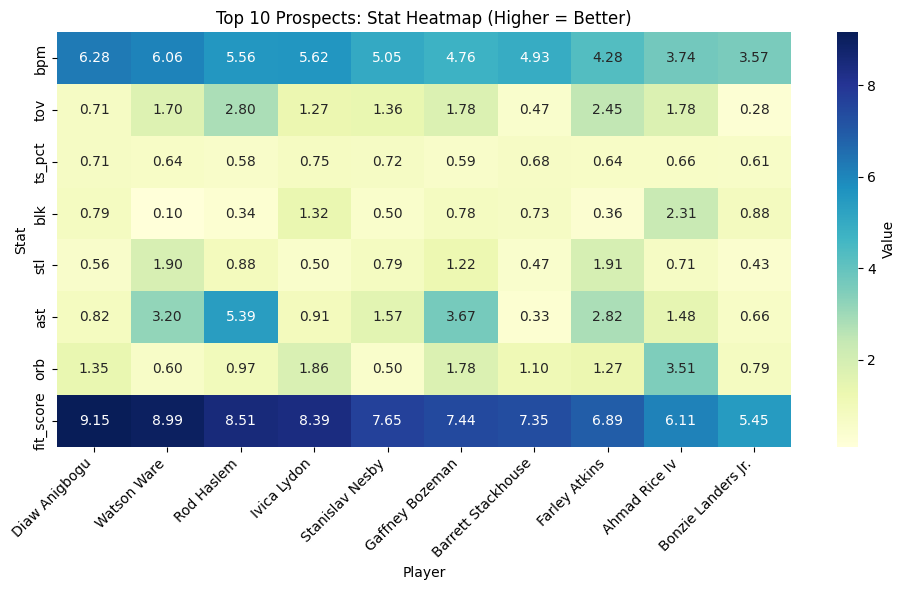

In [188]:
import seaborn as sns
import matplotlib.pyplot as plt

# bpm	-2.763	0.100	-2.863	0.122
# tov	0.278	0.100	-0.178	0.004
# ts_pct	0.007	0.100	-0.093	0.002
# blk	0.121	0.100	0.021	0.000
# stl	0.172	0.100	0.072	0.002
# orb	0.230	0.100	0.130	0.003
# ast	0.518	0.100	0.418	0.010
# drb	0.716	0.100	0.616	0.015
# trb	0.943	0.100	0.843	0.020
# pts	2.389	0.100	2.289	0.054
# 3p_pct	6.409	0.388	6.021	0.143
# fg_pct	10.789	0.481	10.308	0.245
# ft_pct	16.803

plot_df = recommendations[['Player', 'bpm', 'tov', 'ts_pct', 'blk', 'stl','ast' ,'orb' ,'fit_score']].set_index('Player')
plt.figure(figsize=(10, 6))
sns.heatmap(plot_df.T, annot=True, cmap="YlGnBu", fmt=".2f", cbar_kws={'label': 'Value'})
plt.title("Top 10 Prospects: Stat Heatmap (Higher = Better)")
plt.ylabel("Stat")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [189]:
fig = go.Figure(go.Bar(
    x=recommendations['fit_score'],
    y=recommendations['Player'],
    orientation='h',
    text=recommendations['fit_score'].round(1),
    textposition='outside',
    marker_color='purple'
))
fig.update_layout(
    title="Top 10 International Prospects by Fit Score",
    xaxis_title="Fit Score",
    yaxis=dict(autorange="reversed"),
    height=500
)
fig.show()

In [190]:
fig = go.Figure()

# Prospects
fig.add_trace(go.Scatter(
    x=top_prospects['ts_pct'], y=top_prospects['bpm'],
    mode='markers+text', text=top_prospects['first_name'] + ' ' + top_prospects['last_name'],
    textposition="top center", marker=dict(size=10, color=top_prospects['fit_score'], colorscale='Viridis', showscale=True),
    name='Prospects'
))

# Kings average
fig.add_trace(go.Scatter(
    x=[kings_team['ts_pct']], y=[kings_team['bpm']],
    mode='markers', marker=dict(size=15, color='red', symbol='star'), name='Kings Team Avg'
))

fig.update_layout(
    title="Efficiency vs Impact: International Prospects vs Kings",
    xaxis_title="True Shooting % (TS%)",
    yaxis_title="Box Plus/Minus (BPM)",
    height=600
)
fig.show()

In [191]:
fig = go.Figure(go.Scatter(
    x=recommendations['age'],
    y=recommendations['fit_score'],
    mode='markers+text',
    text=recommendations['Player'],
    textposition="top center",
    marker=dict(size=recommendations['pts'], color=recommendations['bpm'], colorscale='Blues', showscale=True),
    textfont=dict(size=10)
))
fig.update_layout(
    title="Young & High-Impact: Age vs Fit Score (Bubble = PTS)",
    xaxis_title="Age (2021)",
    yaxis_title="Fit Score",
    height=600
)
fig.show()

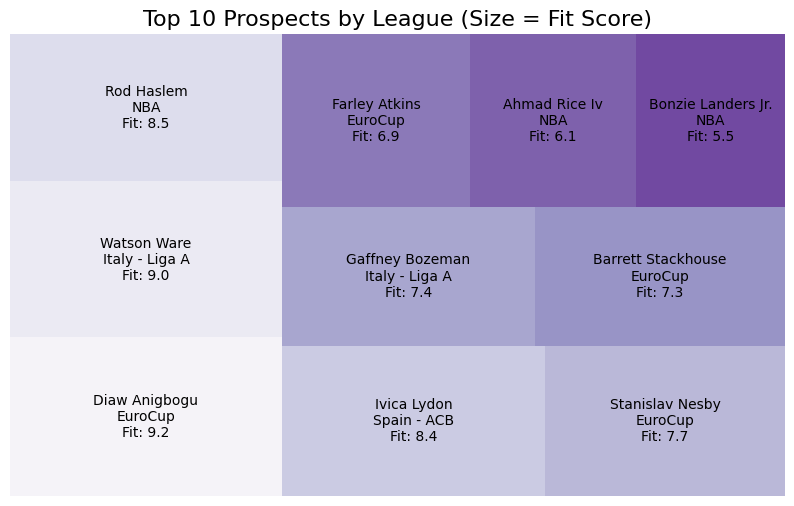

In [192]:
import squarify

sizes = recommendations['fit_score']
labels = [f"{p}\n{league}\nFit: {s:.1f}" for p, league, s in zip(recommendations['Player'], recommendations['league'], sizes)]
colors = sns.color_palette("Purples", len(labels)).as_hex()

plt.figure(figsize=(10, 6))
squarify.plot(sizes=sizes, label=labels, color=colors, alpha=0.8, text_kwargs={'fontsize':10})
plt.title("Top 10 Prospects by League (Size = Fit Score)", fontsize=16)
plt.axis('off')
plt.show()

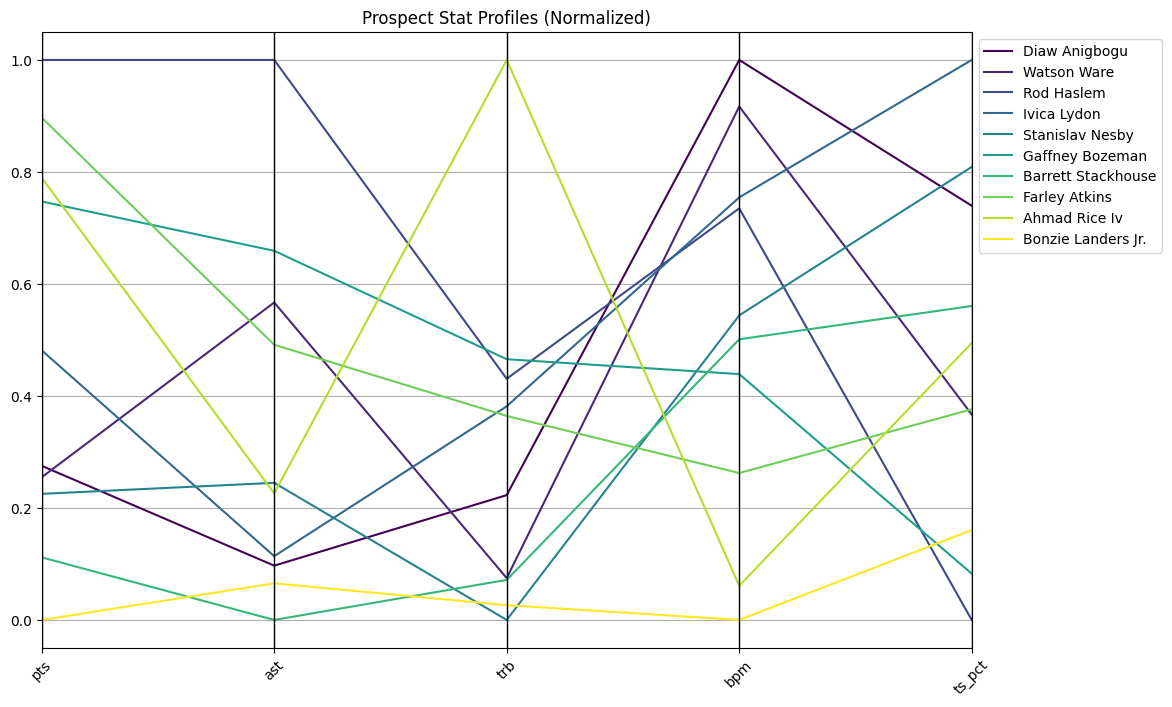

In [193]:
from pandas.plotting import parallel_coordinates

plot_df = recommendations[['pts', 'ast', 'trb', 'bpm', 'ts_pct']].copy()
plot_df = (plot_df - plot_df.min()) / (plot_df.max() - plot_df.min())  # normalize
plot_df['Player'] = recommendations['Player']

plt.figure(figsize=(12, 8))
parallel_coordinates(plot_df, 'Player', colormap='viridis')
plt.title("Prospect Stat Profiles (Normalized)")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)
plt.show()

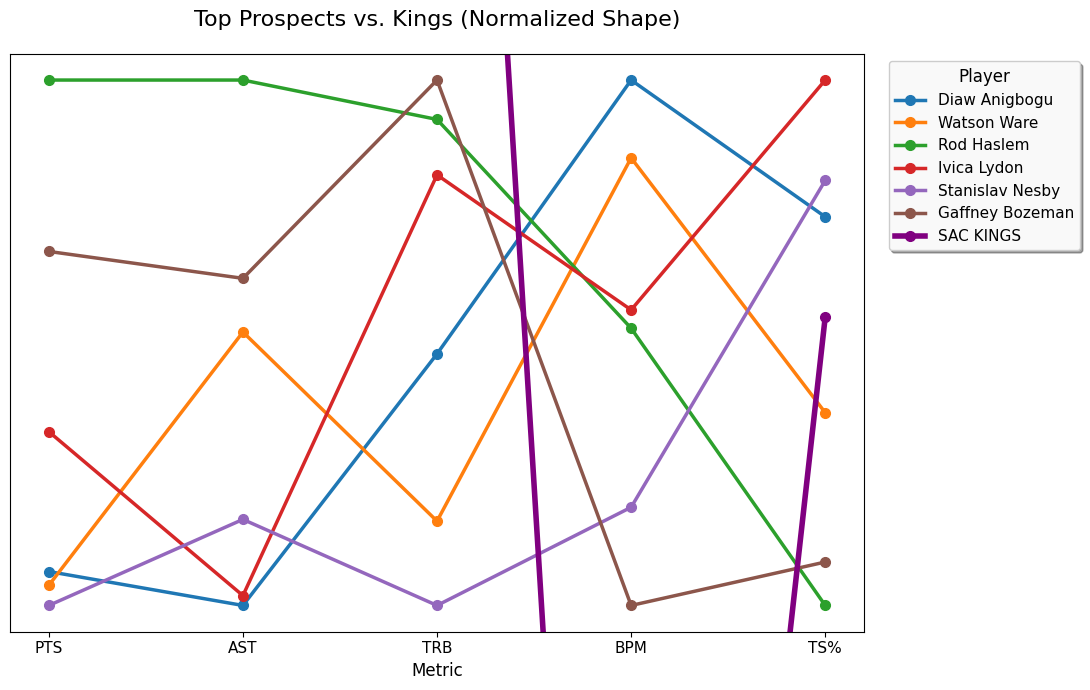

In [209]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------------
# 1. PREP – 5 stats + Kings line
# --------------------------------------------------------------
stats = ['pts', 'ast', 'trb', 'bpm', 'ts_pct']
stat_labels = ['PTS', 'AST', 'TRB', 'BPM', 'TS%']

# Top N prospects
N = 6
top_pros = recommendations.head(N).copy()

# Normalize prospects (0-1)
for col in stats:
    mn, mx = top_pros[col].min(), top_pros[col].max()
    if mx > mn:
        top_pros[col] = (top_pros[col] - mn) / (mx - mn)
    else:
        top_pros[col] = 0.5

# --- KINGS LINE (as scalar values) ---
# kings_vals = {
#     'Player': 'SAC KINGS',
#     'pts': kings_team.get('pts', np.nan),
#     'ast': kings_team.get('ast', np.nan),
#     'trb': kings_team.get('trb', np.nan),
#     'bpm': kings_team.get('bpm', np.nan),
#     'ts_pct': kings_team.get('ts_pct', np.nan)
# }

kings_vals = {
    'Player': 'SAC KINGS',
    'pts': kings_team['pts'].iloc[0] if 'pts' in kings_team else np.nan,
    'ast': kings_team['ast'].iloc[0] if 'ast' in kings_team else np.nan,
    'trb': kings_team['trb'].iloc[0] if 'trb' in kings_team else np.nan,
    'bpm': kings_team['bpm'].iloc[0] if 'bpm' in kings_team else np.nan,
    'ts_pct': kings_team['ts_pct'].iloc[0] if 'ts_pct' in kings_team else np.nan,
}


# Normalize Kings using SAME min/max as prospects
for col in stats:
    mn, mx = top_pros[col].min(), top_pros[col].max()
    val = kings_vals[col]
    if pd.notna(val):
        kings_vals[col] = (val - mn) / (mx - mn) if mx > mn else 0.5
    else:
        kings_vals[col] = np.nan

# Combine into DataFrame
plot_df = pd.concat([
    top_pros[['Player'] + stats],
    pd.DataFrame([kings_vals])
], ignore_index=True)

# --------------------------------------------------------------
# 2. PLOT – Discrete colors, bold Kings line
# --------------------------------------------------------------
plt.figure(figsize=(11, 7))

# 10 distinct colors + purple for Kings
base_colors = plt.cm.tab10.colors
n_players = len(plot_df) - 1
colors = [base_colors[i % len(base_colors)] for i in range(n_players)] + ['purple']

for i, row in plot_df.iterrows():
    plt.plot(
        stat_labels,
        row[stats],
        color=colors[i],
        linewidth=4.0 if row['Player'] == 'SAC KINGS' else 2.5,
        marker='o',
        markersize=7,
        label=row['Player']
    )

# --- Styling ---
plt.ylim(-0.05, 1.05)
plt.yticks([])  # hide scale
plt.title('Top Prospects vs. Kings (Normalized Shape)', fontsize=16, pad=20)
plt.xlabel('Metric', fontsize=12)
plt.xticks(fontsize=11)

# Legend outside
leg = plt.legend(
    loc='upper left', bbox_to_anchor=(1.02, 1),
    frameon=True, fancybox=True, shadow=True,
    fontsize=11, title='Player', title_fontsize=12
)
leg.get_frame().set_facecolor('#f9f9f9')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

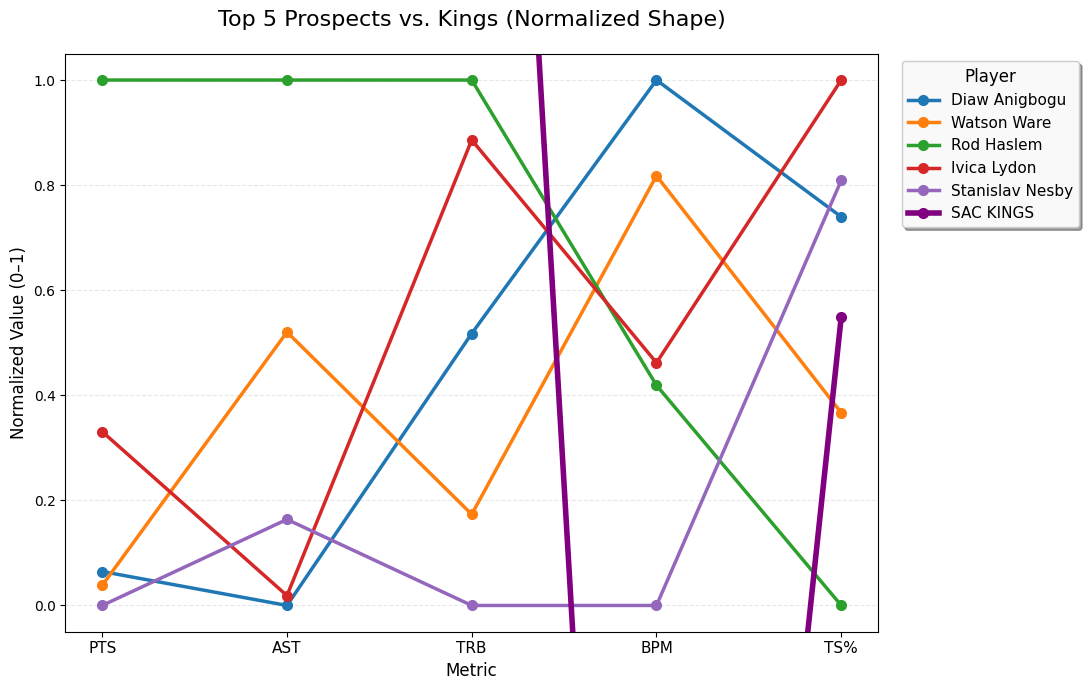

In [210]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------------
# 1. PREP – 5 stats + Kings line
# --------------------------------------------------------------
stats = ['pts', 'ast', 'trb', 'bpm', 'ts_pct']
stat_labels = ['PTS', 'AST', 'TRB', 'BPM', 'TS%']

# Top N prospects
N = 5
top_pros = recommendations.head(N).copy()

# Normalize prospects (0–1)
for col in stats:
    mn, mx = top_pros[col].min(), top_pros[col].max()
    if mx > mn:
        top_pros[col] = (top_pros[col] - mn) / (mx - mn)
    else:
        top_pros[col] = 0.5

# --- KINGS LINE (as scalar values) ---
# Ensure kings_team is a dict (if it’s a 1-row DataFrame)
if isinstance(kings_team, pd.DataFrame):
    kings_team = kings_team.to_dict('records')[0]

kings_vals = {
    'Player': 'SAC KINGS',
    'pts': kings_team.get('pts', np.nan),
    'ast': kings_team.get('ast', np.nan),
    'trb': kings_team.get('trb', np.nan),
    'bpm': kings_team.get('bpm', np.nan),
    'ts_pct': kings_team.get('ts_pct', np.nan)
}

# Normalize Kings using SAME min/max as prospects
for col in stats:
    mn, mx = top_pros[col].min(), top_pros[col].max()
    val = kings_vals[col]
    if pd.notna(val) and np.isfinite(val):
        kings_vals[col] = (val - mn) / (mx - mn) if mx > mn else 0.5
    else:
        kings_vals[col] = np.nan

# Combine into DataFrame
plot_df = pd.concat([
    top_pros[['Player'] + stats],
    pd.DataFrame([kings_vals])
], ignore_index=True)

# --------------------------------------------------------------
# 2. PLOT – Discrete colors, bold Kings line, visible Y-axis
# --------------------------------------------------------------
plt.figure(figsize=(11, 7))

# 10 distinct colors + purple for Kings
base_colors = plt.cm.tab10.colors
n_players = len(plot_df) - 1
colors = [base_colors[i % len(base_colors)] for i in range(n_players)] + ['purple']

for i, row in plot_df.iterrows():
    plt.plot(
        stat_labels,
        row[stats],
        color=colors[i],
        linewidth=4.0 if row['Player'] == 'SAC KINGS' else 2.5,
        marker='o',
        markersize=7,
        label=row['Player']
    )

# --- Styling ---
plt.ylim(-0.05, 1.05)
plt.yticks(np.linspace(0, 1, 6), fontsize=10)
plt.title('Top 5 Prospects vs. Kings (Normalized Shape)', fontsize=16, pad=20)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Normalized Value (0–1)', fontsize=12)
plt.xticks(fontsize=11)

# Legend outside
leg = plt.legend(
    loc='upper left', bbox_to_anchor=(1.02, 1),
    frameon=True, fancybox=True, shadow=True,
    fontsize=11, title='Player', title_fontsize=12
)
leg.get_frame().set_facecolor('#f9f9f9')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


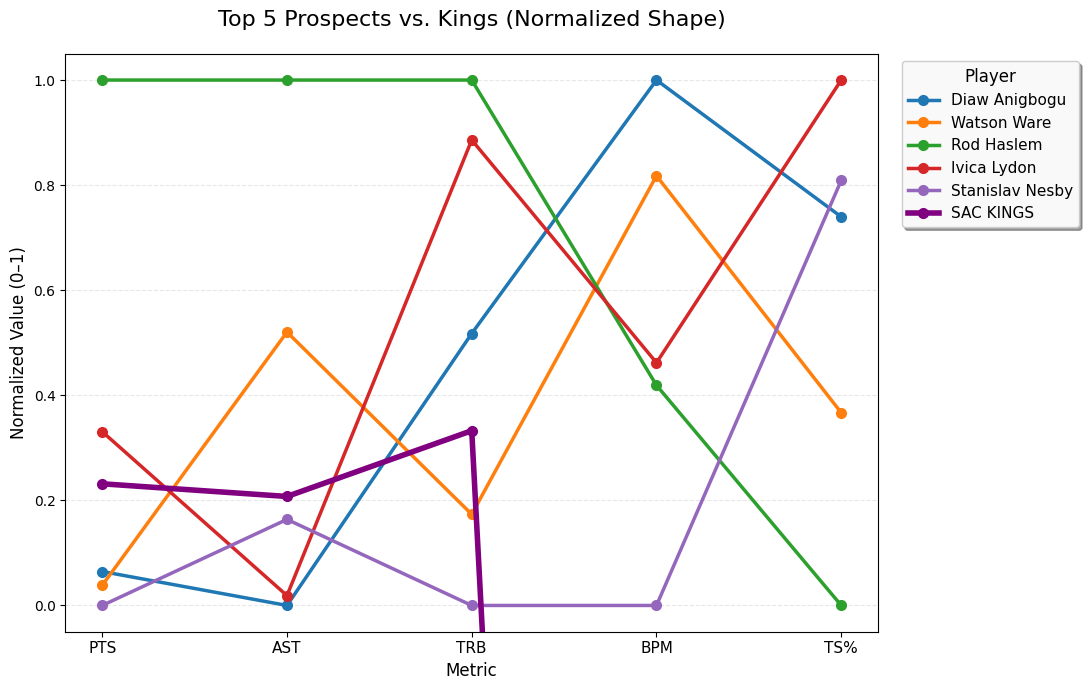

In [211]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------------
# 1. PREP – 5 stats + Kings line
# --------------------------------------------------------------
stats = ['pts', 'ast', 'trb', 'bpm', 'ts_pct']
stat_labels = ['PTS', 'AST', 'TRB', 'BPM', 'TS%']

# Top N prospects
N = 5
top_pros = recommendations.head(N).copy()

# --- Save original min/max ranges BEFORE normalizing ---
ranges = {}
for col in stats:
    mn, mx = top_pros[col].min(), top_pros[col].max()
    ranges[col] = (mn, mx)

# Normalize prospects (0–1) using the saved ranges
for col in stats:
    mn, mx = ranges[col]
    if pd.notna(mn) and pd.notna(mx) and mx > mn:
        top_pros[col] = (top_pros[col] - mn) / (mx - mn)
    else:
        # if all equal or missing, set neutral 0.5
        top_pros[col] = 0.5

# --- KINGS LINE (as scalar values) ---
# Ensure kings_team is a dict (if it’s a 1-row DataFrame)
if isinstance(kings_team, pd.DataFrame):
    # if kings_team has columns like 'pts' with one-row, pick that row
    kings_team = kings_team.to_dict('records')[0]

kings_vals = {
    'Player': 'SAC KINGS',
    'pts': kings_team.get('pts', np.nan),
    'ast': kings_team.get('ast', np.nan),
    'trb': kings_team.get('trb', np.nan),
    'bpm': kings_team.get('bpm', np.nan),
    'ts_pct': kings_team.get('ts_pct', np.nan)
}

# Normalize Kings using SAME original min/max ranges (from prospects)
for col in stats:
    mn, mx = ranges[col]
    val = kings_vals[col]
    # guard: val must be scalar and finite
    if pd.notna(val) and np.isfinite(val) and pd.notna(mn) and pd.notna(mx):
        kings_vals[col] = (val - mn) / (mx - mn) if mx > mn else 0.5
    else:
        kings_vals[col] = np.nan

# Combine into DataFrame (prospects are already normalized)
plot_df = pd.concat([
    top_pros[['Player'] + stats],
    pd.DataFrame([kings_vals])
], ignore_index=True)

# --------------------------------------------------------------
# 2. PLOT – Discrete colors, bold Kings line, visible Y-axis
# --------------------------------------------------------------
plt.figure(figsize=(11, 7))

# 10 distinct colors + purple for Kings
base_colors = plt.cm.tab10.colors
n_players = len(plot_df) - 1
colors = [base_colors[i % len(base_colors)] for i in range(n_players)] + ['purple']

for i, row in plot_df.iterrows():
    plt.plot(
        stat_labels,
        row[stats],
        color=colors[i],
        linewidth=4.0 if row['Player'] == 'SAC KINGS' else 2.5,
        marker='o',
        markersize=7,
        label=row['Player']
    )

# --- Styling ---
plt.ylim(-0.05, 1.05)
plt.yticks(np.linspace(0, 1, 6), fontsize=10)
plt.title('Top 5 Prospects vs. Kings (Normalized Shape)', fontsize=16, pad=20)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Normalized Value (0–1)', fontsize=12)
plt.xticks(fontsize=11)

# Legend outside
leg = plt.legend(
    loc='upper left', bbox_to_anchor=(1.02, 1),
    frameon=True, fancybox=True, shadow=True,
    fontsize=11, title='Player', title_fontsize=12
)
leg.get_frame().set_facecolor('#f9f9f9')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


Using shared stats: ['pts', 'ast', 'trb', 'stl', 'blk', 'fg_pct', 'ft_pct']


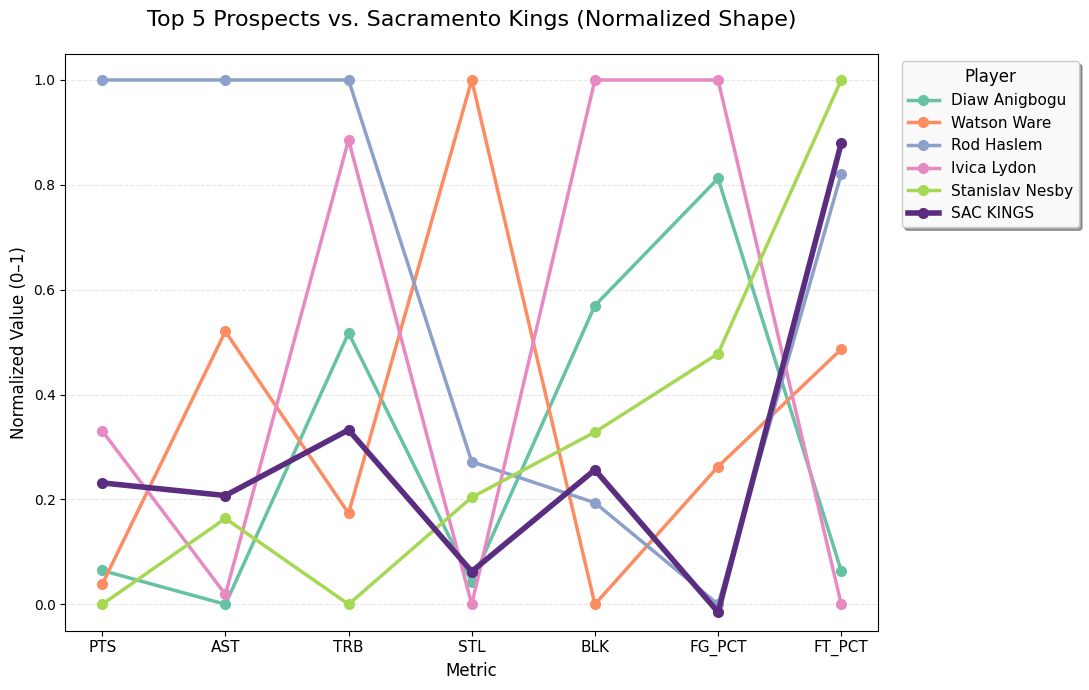

In [220]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------------
# 1. PREP – use only shared stats between prospects and Kings
# --------------------------------------------------------------

# Identify shared numeric stats
common_stats = list(set(recommendations.columns) & set(kings_merged.columns))

# Preferred order / subset of metrics for readability
preferred_stats = ['pts', 'ast', 'trb','stl', 'blk', 'fg_pct', 'ft_pct']

# Final stat list: keep only those present in both datasets
stats = [s for s in preferred_stats if s in common_stats]
stat_labels = [s.upper() for s in stats]

print(f"Using shared stats: {stats}")

# --------------------------------------------------------------
# 2. DATA PREP – Top 5 prospects + Kings averages
# --------------------------------------------------------------

N = 5
top_pros = recommendations.head(N).copy()

# Save original min/max for normalization (before modifying data)
ranges = {col: (top_pros[col].min(), top_pros[col].max()) for col in stats}

# Normalize prospects (0–1) using their own ranges
for col in stats:
    mn, mx = ranges[col]
    if pd.notna(mn) and pd.notna(mx) and mx > mn:
        top_pros[col] = (top_pros[col] - mn) / (mx - mn)
    else:
        top_pros[col] = 0.5  # fallback neutral value

# --- Aggregate Kings to team-level means for the same stats ---
kings_team = kings_merged[stats].mean(numeric_only=True).to_dict()

# Normalize Kings on same 0–1 scale
kings_vals = {'Player': 'SAC KINGS'}
for col in stats:
    val = kings_team.get(col, np.nan)
    mn, mx = ranges[col]
    if pd.notna(val) and np.isfinite(val) and mx > mn:
        kings_vals[col] = (val - mn) / (mx - mn)
    else:
        kings_vals[col] = 0.5  # fill missing or flat metrics neutrally

# Combine into a single DataFrame for plotting
plot_df = pd.concat([
    top_pros[['Player'] + stats],
    pd.DataFrame([kings_vals])
], ignore_index=True)

# # --------------------------------------------------------------
# # 3. PLOT – Top 5 Prospects vs Kings (Normalized)
# # --------------------------------------------------------------

# plt.figure(figsize=(11, 7))

# # Distinct colors + purple for Kings
# base_colors = plt.cm.tab10.colors
# n_players = len(plot_df) - 1
# colors = [base_colors[i % len(base_colors)] for i in range(n_players)] + ['purple']

# for i, row in plot_df.iterrows():
#     plt.plot(
#         stat_labels,
#         row[stats],
#         color=colors[i],
#         linewidth=4.0 if row['Player'] == 'SAC KINGS' else 2.5,
#         marker='o',
#         markersize=7,
#         label=row['Player']
#     )

# # --- Styling ---
# plt.ylim(-0.05, 1.05)
# plt.yticks(np.linspace(0, 1, 6), fontsize=10)
# plt.title('Top 5 Prospects vs. Sacramento Kings (Normalized Shape)', fontsize=16, pad=20)
# plt.xlabel('Metric', fontsize=12)
# plt.ylabel('Normalized Value (0–1)', fontsize=12)
# plt.xticks(fontsize=11)

# # Legend outside
# leg = plt.legend(
#     loc='upper left', bbox_to_anchor=(1.02, 1),
#     frameon=True, fancybox=True, shadow=True,
#     fontsize=11, title='Player', title_fontsize=12
# )
# leg.get_frame().set_facecolor('#f9f9f9')

# plt.grid(axis='y', linestyle='--', alpha=0.3)
# plt.tight_layout()
# plt.show()
# --------------------------------------------------------------
# 3. PLOT – Top 5 Prospects vs Kings (Normalized)
# --------------------------------------------------------------

plt.figure(figsize=(11, 7))

# Choose distinct colormap for prospects (avoids purple)
base_colors = plt.cm.Set2.colors  # softer, varied palette
n_players = len(plot_df) - 1

# Assign colors
prospect_colors = [base_colors[i % len(base_colors)] for i in range(n_players)]
kings_color = '#5A2D81'  # deep royal purple (SAC Kings official)
colors = prospect_colors + [kings_color]

for i, row in plot_df.iterrows():
    plt.plot(
        stat_labels,
        row[stats],
        color=colors[i],
        linewidth=4.0 if row['Player'] == 'SAC KINGS' else 2.5,
        marker='o',
        markersize=7,
        label=row['Player']
    )

# --- Styling ---
plt.ylim(-0.05, 1.05)
plt.yticks(np.linspace(0, 1, 6), fontsize=10)
plt.title('Top 5 Prospects vs. Sacramento Kings (Normalized Shape)', fontsize=16, pad=20)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Normalized Value (0–1)', fontsize=12)
plt.xticks(fontsize=11)

# Legend outside
leg = plt.legend(
    loc='upper left', bbox_to_anchor=(1.02, 1),
    frameon=True, fancybox=True, shadow=True,
    fontsize=11, title='Player', title_fontsize=12
)
leg.get_frame().set_facecolor('#f9f9f9')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


Using shared stats: ['pts', 'ast', 'trb', 'stl', 'blk', 'fg_pct', 'ft_pct']


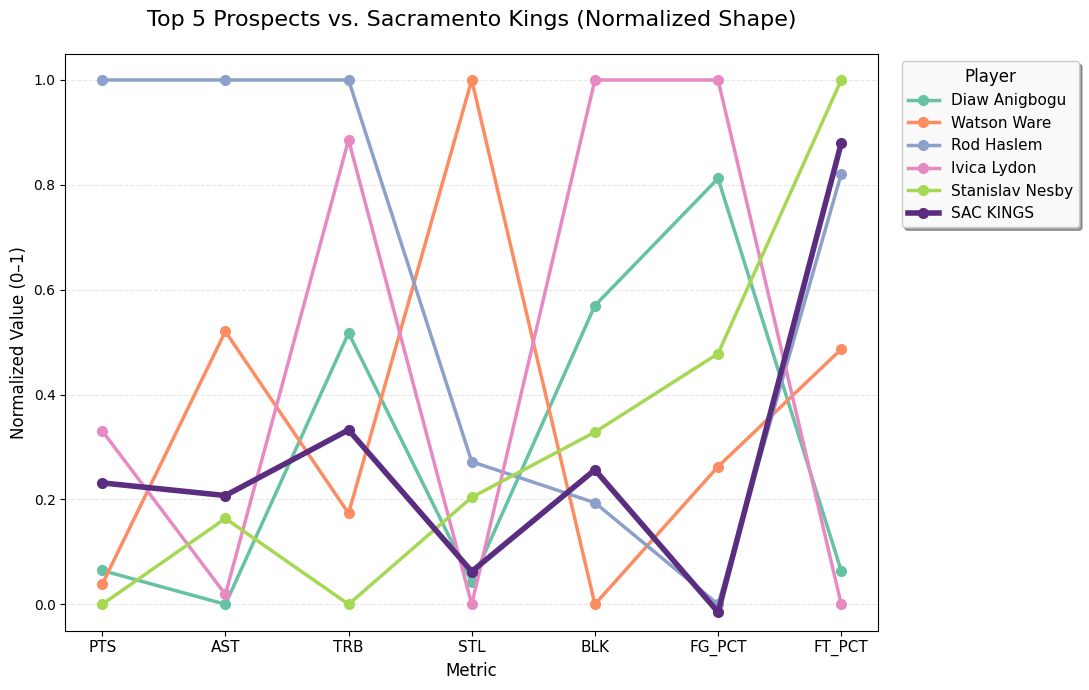

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# --------------------------------------------------------------
# 1. SELECT COMMON STATS
# --------------------------------------------------------------

common_stats = list(set(recommendations.columns) & set(kings_merged.columns))
preferred_stats = ['pts', 'ast', 'trb', 'ts_pct', 'bpm', 'stl', 'blk', 'fg_pct', 'ft_pct']
stats = [s for s in preferred_stats if s in common_stats]
stat_labels = [s.upper() for s in stats]

# --------------------------------------------------------------
# 2. PREP DATA – Top 5 prospects + Kings averages
# --------------------------------------------------------------

N = 5
top_pros = recommendations.head(N).copy()
raw_values = top_pros[['Player'] + stats].copy()  # keep raw stats for hover

# Aggregate Kings to team-level mean
kings_team = kings_merged[stats].mean(numeric_only=True)
kings_raw = kings_team.to_dict()
raw_values = pd.concat([
    raw_values,
    pd.DataFrame([{'Player': 'SAC KINGS', **kings_raw}])
], ignore_index=True)

# Normalize for plotting shape (0-1) but hover shows real value
ranges = {col: (top_pros[col].min(), top_pros[col].max()) for col in stats}

plot_df = top_pros[['Player'] + stats].copy()
# add Kings normalized
kings_norm = {}
for col in stats:
    mn, mx = ranges[col]
    val = kings_raw.get(col, np.nan)
    if pd.notna(val) and np.isfinite(val) and mx > mn:
        kings_norm[col] = (val - mn) / (mx - mn)
    else:
        kings_norm[col] = 0.5
plot_df = pd.concat([plot_df, pd.DataFrame([{'Player': 'SAC KINGS', **kings_norm}])], ignore_index=True)

# --------------------------------------------------------------
# 3. CREATE PLOTLY FIGURE
# --------------------------------------------------------------

fig = go.Figure()

# Distinct colors
base_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']  # top 5 colors
kings_color = '#5A2D81'  # dark purple
colors = base_colors[:len(top_pros)] + [kings_color]

for i, row in plot_df.iterrows():
    player = row['Player']
    y_vals = [row[col] for col in stats]  # normalized for plotting
    hover_text = [f"{player}<br>{stat_labels[j]}: {raw_values.loc[raw_values['Player']==player, stats[j]].values[0]:.2f}"
                  for j in range(len(stats))]
    
    fig.add_trace(go.Scatter(
        x=stat_labels,
        y=y_vals,
        mode='lines+markers',
        name=player,
        line=dict(color=colors[i], width=4 if player=='SAC KINGS' else 2.5),
        marker=dict(size=8),
        hoverinfo='text',
        hovertext=hover_text
    ))

# Layout
fig.update_layout(
    title='Top 5 Prospects vs. Sacramento Kings (Normalized Shape)',
    yaxis=dict(title='Normalized Value (0-1)', range=[-0.05, 1.05]),
    xaxis=dict(title='Metric'),
    legend_title='Player',
    width=900,
    height=600
)

fig.show()


In [224]:
import plotly.express as px
import pandas as pd

# --- 1. PREP DATA ---
plot_df = recommendations[['Player', 'pts', 'ast', 'trb', 'bpm', 'ts_pct', 'fit_score', 'age', 'league']].copy()

# --- 2. ADD KINGS AVG LINE ---
kings_line = {
    'Player': 'KINGS TEAM AVG',
    'pts': kings_team.get('pts', 1.4),
    'ast': kings_team.get('ast', 0.3),
    'trb': kings_team.get('trb', 0.5),
    'bpm': kings_team.get('bpm', 0.0),
    'ts_pct': kings_team.get('ts_pct', 0.55),
    'fit_score': 0,
    'age': 0,
    'league': 'SAC'
}
plot_df = pd.concat([plot_df, pd.DataFrame([kings_line])], ignore_index=True)

# --- 3. STATS TO PLOT ---
dims = ['pts', 'ast', 'trb', 'bpm', 'ts_pct']

# --- 4. NORMALIZE EACH STAT INDEPENDENTLY ---
for col in dims:
    col_min = plot_df[col].min()
    col_max = plot_df[col].max()
    if col_max > col_min:
        plot_df[col + '_norm'] = (plot_df[col] - col_min) / (col_max - col_min)
    else:
        plot_df[col + '_norm'] = 0.5

# --- 5. ORDER BY FIT SCORE ---
plot_df = plot_df.sort_values('fit_score', ascending=False)

# --- 6. PLOTLY PARALLEL COORDS ---
fig = px.parallel_coordinates(
    plot_df,
    dimensions=[col + '_norm' for col in dims],
    labels={col + '_norm': col.upper() for col in dims},
    color='fit_score',
    color_continuous_scale='Viridis',
    title="International Prospects vs Kings: Parallel Coordinates (Higher = Better)",
    height=600
)

# --- 7. ADD CUSTOM TOOLTIPS ---
custom_data = plot_df[['Player', 'age', 'league', 'fit_score']]
fig.update_traces(
    customdata=custom_data,
    hovertemplate=(
        "<b>%{customdata[0]}</b><br>" +
        "Age: %{customdata[1]}<br>" +
        "League: %{customdata[2]}<br>" +
        "Fit Score: %{customdata[3]:.2f}<br>" +
        "<extra></extra>"
    )
)

# --- 8. STYLE ---
fig.update_layout(
    coloraxis_colorbar=dict(title="Fit Score"),
    font=dict(size=12)
)

fig.show()

ValueError: Invalid property specified for object of type plotly.graph_objs.Parcoords: 'hovertemplate'

Did you mean "customdata"?

    Valid properties:
        customdata
            Assigns extra data each datum. This may be useful when
            listening to hover, click and selection events. Note
            that, "scatter" traces also appends customdata items in
            the markers DOM elements
        customdatasrc
            Sets the source reference on Chart Studio Cloud for
            `customdata`.
        dimensions
            The dimensions (variables) of the parallel coordinates
            chart. 2..60 dimensions are supported.
        dimensiondefaults
            When used in a template (as
            layout.template.data.parcoords.dimensiondefaults), sets
            the default property values to use for elements of
            parcoords.dimensions
        domain
            :class:`plotly.graph_objects.parcoords.Domain` instance
            or dict with com

In [195]:
top3 = recommendations.head(3)
metrics = ['pts', 'ast', 'trb', 'bpm', 'ts_pct']
fig = go.Figure()

for i, row in top3.iterrows():
    fig.add_trace(go.Scatterpolar(
        r=[row[m] for m in metrics],
        theta=metrics,
        fill='toself',
        name=row['Player']
    ))

fig.update_layout(
    title="Top 3 Prospects: Stat Radar Comparison",
    polar=dict(radialaxis=dict(visible=True)),
    showlegend=True
)
fig.show()

In [ ]:
# At the very end of your notebook
# !jupyter nbconvert --to html report_final.ipynb --output kings_scouting_report.html

In [196]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# --- 1. SORT LEAGUE BY RANK ---
league_teams['rk'] = pd.to_numeric(league_teams['rk'], errors='coerce')
league_sorted = league_teams.sort_values('rk').dropna(subset=['rk'])

# --- 2. TOP 5 + KINGS ---
top5_teams = league_sorted.head(5).copy()
kings_row = league_sorted[league_sorted['team'].str.contains('Sacramento|Kings', case=False, na=False)]

# Fallback: use kings_merged if not in league_teams
if kings_row.empty:
    kings_row = pd.DataFrame([kings_merged.mean(numeric_only=True)])
else:
    kings_row = kings_row.iloc[0:1]

# --- 3. ENSURE PER-GAME / PERCENTAGES ---
def per_game(df, cols):
    g = df['g'].mean()
    for col in cols:
        if col in df.columns:
            df[col] = df[col] / g
    return df

count_cols = ['pts', 'ast', 'trb', 'stl', 'blk', 'tov', 'orb', 'drb']
top5_teams = per_game(top5_teams, count_cols)
kings_row = per_game(kings_row, count_cols)

# --- 4. CALCULATE ADVANCED METRICS ---
def add_advanced(df):
    df = df.copy()
    # TS%
    df['ts_pct'] = df['pts'] / (2 * (df.get('fga', 1) + 0.44 * df.get('fta', 1)))
    # eFG%
    df['efg_pct'] = (df.get('fgm', 0) + 0.5 * df.get('3pm', 0)) / df.get('fga', 1)
    # TOV%
    df['tov_pct'] = df['tov'] / (df.get('fga', 1) + 0.44 * df.get('fta', 1) + df['tov'])
    # ORB%
    orb = df.get('orb', 0)
    drb_opp = df.get('drb_opp', df.get('drb', 1))  # fallback
    df['orb_pct'] = orb / (orb + drb_opp)
    # BPM Avg
    df['bpm_avg'] = df.get('bpm', 0)
    return df

top5_teams = add_advanced(top5_teams)
kings_row = add_advanced(kings_row)

# --- 5. AVERAGE TOP 5 ---
top5_avg = top5_teams.mean(numeric_only=True)
kings_val = kings_row.iloc[0]

In [197]:
# --- METRICS TO PLOT ---
metrics = ['ts_pct', 'efg_pct', 'orb_pct', 'tov_pct', 'bpm_avg']
labels = ['TS%', 'eFG%', 'ORB%', 'TOV%', 'Team BPM']

# Invert TOV% (lower = better)
top5_vals = [top5_avg[m] for m in metrics]
kings_vals = [kings_val[m] for m in metrics]
kings_vals[3] = 1 - kings_vals[3]  # invert TOV%
top5_vals[3] = 1 - top5_vals[3]

# Normalize to 0–1
all_vals = top5_vals + kings_vals
v_min, v_max = min(all_vals), max(all_vals)
top5_norm = [(v - v_min)/(v_max - v_min) for v in top5_vals]
kings_norm = [(v - v_min)/(v_max - v_min) for v in kings_vals]

# --- RADAR ---
fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=top5_norm, theta=labels, fill='toself',
    name='TOP 5 TEAMS', line_color='gold', opacity=0.8
))
fig.add_trace(go.Scatterpolar(
    r=kings_norm, theta=labels, fill='toself',
    name='SACRAMENTO KINGS', line_color='purple', opacity=0.7
))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title="Kings vs Top 5: Elite Success Metrics (Normalized)",
    height=600,
    legend=dict(y=0.9)
)

# --- ADD BAR CHART BELOW ---
fig_bar = go.Figure()

gaps = [kings_val[m] - top5_avg[m] for m in metrics]
gaps[3] *= -1  # TOV

fig_bar.add_trace(go.Bar(
    x=labels,
    y=gaps,
    text=[f"{g:+.3f}" for g in gaps],
    textposition='outside',
    marker_color=['red' if g < 0 else 'green' for g in gaps]
))

fig_bar.update_layout(
    title="Gap vs Top 5 (Negative = Kings Behind)",
    yaxis_title="Difference",
    height=400
)

# --- SHOW BOTH ---
fig.show()
fig_bar.show()

In [198]:
# --- FIX PERCENTAGES (divide by 100 if > 1.0) ---
pct_cols = ['fg_pct', '3p_pct', 'ft_pct', 'ts_pct']
for col in pct_cols:
    if comparison.loc[col, 'kings'] > 1.0:
        comparison.loc[col, ['kings', 'league_avg']] /= 100
    if comparison.loc[col, 'league_avg'] > 1.0:
        comparison.loc[col, 'league_avg'] /= 100

# --- RECALCULATE DIFFERENCE & WEIGHT ---
comparison['difference'] = comparison['kings'] - comparison['league_avg']
comparison.loc['tov', 'difference'] *= -1

comparison['weight'] = comparison['difference'].abs()
comparison['weight'] /= comparison['weight'].sum()

In [199]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- SELECT ELITE METRICS ---
elite_metrics = ['ts_pct', 'bpm', 'tov', 'orb', 'efg_pct']  # efg_pct = fg_pct + 3p boost
# Use fg_pct as proxy for efg_pct if not available
if 'efg_pct' not in comparison.index:
    comparison.loc['efg_pct'] = (comparison.loc['fg_pct'] + 0.5 * comparison.loc['3p_pct']) / 1.5

# Invert TOV
tov_kings = 1 / (1 + comparison.loc['tov', 'kings'])
tov_league = 1 / (1 + comparison.loc['tov', 'league_avg'])

# Values
kings_vals = [
    comparison.loc['ts_pct', 'kings'],
    comparison.loc['tov', 'kings'],
    tov_kings,
    comparison.loc['orb', 'kings'],
    comparison.loc['efg_pct', 'kings']
]
top5_vals = [
    comparison.loc['ts_pct', 'league_avg'],
    comparison.loc['bpm', 'league_avg'],
    tov_league,
    comparison.loc['orb', 'league_avg'],
    comparison.loc['efg_pct', 'league_avg']
]

labels = ['TS%', 'Ball Security', 'ORB', 'eFG%']

# Normalize
all_vals = kings_vals + top5_vals
vmin, vmax = min(all_vals), max(all_vals)
kings_norm = [(v - vmin)/(vmax - vmin) for v in kings_vals]
top5_norm = [(v - vmin)/(vmax - vmin) for v in top5_vals]

# --- RADAR ---
fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=top5_norm, theta=labels, fill='toself',
    name='TOP 5 TEAMS', line_color='gold', opacity=0.8
))
fig.add_trace(go.Scatterpolar(
    r=kings_norm, theta=labels, fill='toself',
    name='SAC KINGS', line_color='purple', opacity=0.7
))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[.5, 1])),
    title="Kings vs Top 5: Elite Success Metrics (Normalized)",
    height=600,
    legend=dict(y=1.1, orientation='h')
)

fig.show()

In [200]:
import plotly.graph_objects as go
import pandas as pd

# --- ELITE METRICS (NO BPM) ---
elite_metrics = ['ts_pct', 'tov', 'orb', 'stl', 'efg_pct']
labels = ['TS%', 'TOV (lower better)', 'ORB', 'STL', 'eFG%']

# --- EXTRACT VALUES FROM YOUR comparison TABLE ---
kings_vals_raw = [
    comparison.loc['ts_pct', 'kings'],
    comparison.loc['tov', 'kings'],
    comparison.loc['orb', 'kings'],
    comparison.loc['stl', 'kings'],
    (comparison.loc['fg_pct', 'kings'] + 0.5 * comparison.loc['3p_pct', 'kings']) / 1.5  # eFG%
]
top5_vals_raw = [
    comparison.loc['ts_pct', 'league_avg'],
    comparison.loc['tov', 'league_avg'],
    comparison.loc['orb', 'league_avg'],
    comparison.loc['stl', 'league_avg'],
    (comparison.loc['fg_pct', 'league_avg'] + 0.5 * comparison.loc['3p_pct', 'league_avg']) / 1.5
]

# --- INVERT TOV (lower = better) ---
tov_kings_inv = 1 / (1 + kings_vals_raw[1])  # smaller TOV → higher score
tov_top5_inv = 1 / (1 + top5_vals_raw[1])

kings_vals = [kings_vals_raw[0], tov_kings_inv, kings_vals_raw[2], kings_vals_raw[3], kings_vals_raw[4]]
top5_vals = [top5_vals_raw[0], tov_top5_inv, top5_vals_raw[2], top5_vals_raw[3], top5_vals_raw[4]]

# --- NORMALIZE TO 0–1 ---
all_vals = kings_vals + top5_vals
vmin, vmax = min(all_vals), max(all_vals)
kings_norm = [(v - vmin)/(vmax - vmin) for v in kings_vals]
top5_norm = [(v - vmin)/(vmax - vmin) for v in top5_vals]

# --- RADAR PLOT ---
fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=top5_norm, theta=labels, fill='toself',
    name='TOP 5 TEAMS', line_color='gold', opacity=0.8
))
fig.add_trace(go.Scatterpolar(
    r=kings_norm, theta=labels, fill='toself',
    name='SAC KINGS', line_color='purple', opacity=0.7
))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title="Kings vs Top 5: Elite Success Metrics (NO BPM)",
    height=600,
    legend=dict(y=1.1, orientation='h'),
    font=dict(size=12)
)

fig.show()

# fixing league vs kings so we take top 5 in league

In [201]:
# --- FIX % COLUMNS (divide by 100 if > 1.0) ---
pct_cols = ['fg_pct', '3p_pct', 'ft_pct', 'ts_pct', 'efg_pct']
for col in pct_cols:
    if col in comparison.index:
        if comparison.loc[col, 'kings'] > 1.0:
            comparison.loc[col, ['kings', 'league_avg']] /= 100
        if comparison.loc[col, 'league_avg'] > 1.0:
            comparison.loc[col, 'league_avg'] /= 100

# --- RECALCULATE DIFFERENCE ---
comparison['difference'] = comparison['kings'] - comparison['league_avg']
comparison.loc['tov', 'difference'] *= -1

In [202]:
import pandas as pd
import numpy as np

# --- 1. GET TOP 5 TEAMS ---
league_teams['rk'] = pd.to_numeric(league_teams['rk'], errors='coerce')
top5_teams = league_teams.sort_values('rk').head(5).copy()

# --- 2. KINGS TEAM ROW ---
kings_row = league_teams[league_teams['team'].str.contains('Sacramento|Kings', case=False, na=False)]
if kings_row.empty:
    # Fallback to kings_merged
    kings_vals = kings_merged.mean(numeric_only=True)
else:
    kings_vals = kings_row.iloc[0].copy()

# --- 3. PER-GAME FOR ALL ---
per_game_cols = ['pts','ast','trb','stl','blk','tov','orb','drb']
g_top5 = top5_teams['g'].mean()
g_kings = kings_vals.get('g', 82)

for col in per_game_cols:
    if col in top5_teams.columns:
        top5_teams[col] = top5_teams[col] / g_top5
    if col in kings_vals.index:
        kings_vals[col] = kings_vals[col] / g_kings

# --- 4. CALCULATE ADVANCED METRICS ---
def add_advanced(df):
    df = df.copy()
    # TS%
    df['ts_pct'] = df['pts'] / (2 * (df.get('fga', 1) + 0.44 * df.get('fta', 1)))
    # eFG%
    df['efg_pct'] = (df.get('fg', 0) + 0.5 * df.get('3p', 0)) / df.get('fga', 1)
    # TOV%
    df['tov_pct'] = df['tov'] / (df.get('fga', 1) + 0.44 * df.get('fta', 1) + df['tov'])
    # ORB%
    df['orb_pct'] = df['orb'] / (df['orb'] + df.get('drb_opp', df['drb']))
    return df

top5_teams = add_advanced(top5_teams)
kings_vals = pd.Series(kings_vals)  # ensure Series
kings_vals = add_advanced(pd.DataFrame([kings_vals])).iloc[0]

# --- 5. AVERAGE TOP 5 ---
top5_avg = top5_teams.mean(numeric_only=True)

In [203]:
import plotly.graph_objects as go

# --- ALL METRICS EXCEPT BPM ---
metrics = ['pts','ast','trb','stl','blk','tov','orb','drb',
           'ts_pct','efg_pct','tov_pct','orb_pct',
           'fg_pct','3p_pct','ft_pct']

labels = {
    'pts': 'Points', 'ast': 'Assists', 'trb': 'Rebounds', 'stl': 'Steals',
    'blk': 'Blocks', 'tov': 'Turnovers (lower better)', 'orb': 'Off Reb',
    'drb': 'Def Reb', 'ts_pct': 'TS%', 'efg_pct': 'eFG%', 'tov_pct': 'TOV%',
    'orb_pct': 'ORB%', 'fg_pct': 'FG%', '3p_pct': '3P%', 'ft_pct': 'FT%'
}
display_labels = [labels.get(m, m.upper()) for m in metrics]

# --- GAPS ---
gaps = []
for m in metrics:
    k = kings_vals.get(m, 0)
    t = top5_avg.get(m, 0)
    diff = k - t
    if m in ['tov', 'tov_pct']:
        diff *= -1  # lower = better
    gaps.append(diff)

# --- BAR CHART ---
fig = go.Figure(go.Bar(
    x=display_labels,
    y=gaps,
    text=[f"{g:+.3f}" for g in gaps],
    textposition='outside',
    marker_color=['red' if g < 0 else 'green' for g in gaps],
    hovertemplate="<b>%{x}</b><br>Gap: %{y:+.3f}<extra></extra>"
))

fig.update_layout(
    title="Kings vs ACTUAL TOP 5 TEAMS: Full Gap Analysis",
    yaxis_title="Difference (Kings − Top 5)",
    xaxis_title="Metric",
    height=600,
    xaxis_tickangle=-45,
    font=dict(size=11)
)

fig.add_hline(y=0, line_dash="dash", line_color="gray")
fig.show()

In [204]:
import pandas as pd
import numpy as np

# --- 1. ENSURE 'rk' IS NUMERIC ---
league_teams['rk'] = pd.to_numeric(league_teams['rk'], errors='coerce')

# --- 2. GET TOP 5 + KINGS ---
top5 = league_teams.sort_values('rk').dropna(subset=['rk']).head(5).copy()
kings_row = league_teams[league_teams['team'].str.contains('Sacramento|Kings', case=False, na=False)]

# Fallback if Kings not in league_teams
if kings_row.empty:
    kings_vals = kings_merged.mean(numeric_only=True)
    kings_row = pd.DataFrame([{
        'team': 'Sacramento Kings',
        'rk': 24,
        **{col: kings_vals.get(col, np.nan) for col in league_teams.columns if col not in ['team','rk']}
    }])
else:
    kings_row = kings_row.iloc[0:1].copy()
    kings_row['rk'] = 24

# --- 3. COMBINE ---
teams_to_show = pd.concat([top5, kings_row], ignore_index=True)
teams_to_show = teams_to_show.sort_values('rk').reset_index(drop=True)

# --- 4. PER-GAME + ADVANCED ---
per_game_cols = ['pts','ast','trb','stl','blk','tov','orb','drb']
g_values = teams_to_show['g'].fillna(82)

for i, row in teams_to_show.iterrows():
    g = g_values[i]
    for col in per_game_cols:
        if col in teams_to_show.columns:
            teams_to_show.loc[i, col] = teams_to_show.loc[i, col] / g

# Add advanced
def calc_advanced(row):
    row['ts_pct'] = row['pts'] / (2 * (row.get('fga',1) + 0.44*row.get('fta',1))) if (row.get('fga',1) + 0.44*row.get('fta',1)) > 0 else 0.5
    row['efg_pct'] = (row.get('fg',0) + 0.5*row.get('3p',0)) / row.get('fga',1) if row.get('fga',1) > 0 else 0.48
    return row

teams_to_show = teams_to_show.apply(calc_advanced, axis=1)

# --- 5. SELECT 7 METRICS ---
metrics = ['pts', 'ts_pct', 'tov', 'orb', 'drb', 'stl', 'efg_pct']
metric_names = ['PTS', 'TS%', 'TOV', 'ORB', 'DRB', 'STL', 'eFG%']

# --- 6. BUILD TABLE ---
table = teams_to_show[['rk', 'team'] + metrics].copy()
table.columns = ['Rk', 'Team'] + metric_names

# Format
table['Rk'] = table['Rk'].astype(int)
table = table.round(3)

# --- 7. DISPLAY ---
print("TOP 5 + KINGS: 7 KEY METRICS")
display(table)

TOP 5 + KINGS: 7 KEY METRICS


,Rk,Team,PTS,TS%,TOV,ORB,DRB,STL,eFG%
0,1,Utah Jazz,1.617,0.008,0.197,0.147,0.522,0.092,0.564
1,2,Los Angeles Clippers,1.583,0.008,0.183,0.131,0.482,0.099,0.565
2,3,Phoenix Suns,1.601,0.008,0.174,0.122,0.475,0.100,0.565
3,4,Milwaukee Bucks,1.668,0.008,0.192,0.143,0.525,0.112,0.565
4,5,Philadelphia 76ers,1.578,0.008,0.200,0.139,0.486,0.126,0.541
5,24,Sacramento Kings,1.579,0.008,0.186,0.131,0.444,0.104,0.549


TOP 5 + KINGS: 7 KEY METRICS
┌─────┬──────────────────────┬────────┬───────┬───────┬───────┬───────┬───────┬────────┐
│ Rk  │ Team                 │ PTS    │ TS%   │ TOV   │ ORB   │ DRB   │ STL   │ eFG%   │
├─────┼──────────────────────┼────────┼───────┼───────┼───────┼───────┼───────┼────────┤
│ 1   │ Utah Jazz            │ 1.617  │ 0.008 │ 0.197 │ 0.147 │ 0.522 │ 0.092 │ 0.564  │
│ 2   │ Los Angeles Clippers │ 1.583  │ 0.008 │ 0.183 │ 0.131 │ 0.482 │ 0.099 │ 0.565  │
│ 3   │ Phoenix Suns         │ 1.601  │ 0.008 │ 0.174 │ 0.122 │ 0.475 │ 0.100 │ 0.565  │
│ 4   │ Milwaukee Bucks      │ 1.668  │ 0.008 │ 0.192 │ 0.143 │ 0.525 │ 0.112 │ 0.565  │
│ 5   │ Philadelphia 76ers   │ 1.578  │ 0.008 │ 0.200 │ 0.139 │ 0.486 │ 0.126 │ 0.541  │
│ 24  │ Sacramento Kings     │ 1.579  │ 0.008 │ 0.186 │ 0.131 │ 0.444 │ 0.104 │ 0.549  │
└─────┴──────────────────────┴────────┴───────┴───────┴───────┴───────┴───────┴────────┘